# Actividad 6: Estrategias de inversión
### Operaciones con vectores y matrices — Álgebra Lineal

**Objetivo:** comparar la evolución de un capital inicial $C$ invertido en 6 compañías bajo dos estrategias distintas — *Buy and Hold* y *Rebalanceo Diario* — y contrastarlas contra el rendimiento del S&P500, usando operaciones matriciales y vectoriales con NumPy.

**Periodo de análisis:** 01/01/2024 al 18/02/2025

**Compañías utilizadas:** Apple (AAPL), Amazon (AMZN), Microsoft (MSFT), Google (GOOGL), Meta (META), Nvidia (NVDA)

---


## 0. Librerías necesarias

Antes de empezar, instalamos y cargamos las librerías que vamos a usar:

- **`yfinance`**: para descargar los precios históricos directamente desde Yahoo Finance.
- **`numpy`**: para representar los precios como matrices/vectores y hacer las operaciones de álgebra lineal.
- **`pandas`**: para manejar las fechas y tablas de forma cómoda antes de convertir a NumPy.
- **`matplotlib`**: para graficar el resultado final.

Si no las tienes instaladas, descomenta la siguiente línea y ejecútala una sola vez.

In [2]:
# !pip install yfinance numpy pandas matplotlib

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Escenario y datos

Un inversor quiere comparar la evolución de un capital inicial $C$ invertido en 6 compañías, desde el 01/01/2024 hasta el 18/02/2025.

Necesitamos armar:

- $P \in \mathbb{R}^{T \times 6}$: matriz de precios diarios, con $T$ días y 6 compañías.
- Un vector de precios del S&P500 para el mismo período.
- El capital inicial $C$ (usamos el valor del S&P500 el primer día).

Definimos los tickers y el rango de fechas.

In [3]:
tickers = ["AAPL", "AMZN", "MSFT", "GOOGL", "META", "NVDA"]
fecha_inicio = "2024-01-01"
fecha_fin = "2025-02-18"

### 1.1 Descargar los precios con `yfinance`

Descargamos los precios de cierre ajustados (`auto_adjust=True` corrige por dividendos y splits, lo cual es importante para que la riqueza calculada sea realista) de las 6 acciones y del S&P500 (ticker `^GSPC`).

In [4]:
# Precios de las 6 acciones
data = yf.download(tickers, start=fecha_inicio, end=fecha_fin, auto_adjust=True)["Close"]

# Precios del S&P500
sp500 = yf.download("^GSPC", start=fecha_inicio, end=fecha_fin, auto_adjust=True)["Close"]

[*********************100%***********************]  5 of 6 completed
[*********************100%***********************]  1 of 1 completed


### 1.2 Alinear las fechas

Antes de convertir a matrices, nos aseguramos de que ambas series (acciones y S&P500) tengan exactamente las mismas fechas, por si algún día hiciera falta en una de las dos.

In [5]:
data = data.dropna()
sp500 = sp500.reindex(data.index).dropna()
data = data.reindex(sp500.index)

fechas = data.index
print("Rango de fechas:", fechas.min().date(), "a", fechas.max().date())
print("Número de días de trading:", len(fechas))

Rango de fechas: 2024-01-02 a 2025-02-14
Número de días de trading: 282


### 1.3 Construir la matriz de precios $P$ y el vector del S&P500

Convertimos los DataFrames de pandas a arreglos de NumPy, que es con lo que vamos a operar matricialmente de aquí en adelante.

In [6]:
P = data.to_numpy()                       # Matriz P: T x 6
sp500_vec = sp500.to_numpy().flatten()     # Vector: T

T, N = P.shape

print("Forma de P (T x N):", P.shape)
print("Forma del vector S&P500 (T,):", sp500_vec.shape)
print("Compañías (columnas de P):", list(data.columns))

Forma de P (T x N): (282, 6)
Forma del vector S&P500 (T,): (282,)
Compañías (columnas de P): ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']


In [7]:
data.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,
2024-01-02,183.403992,149.929993,136.955566,343.275543,363.801544,48.082531
2024-01-03,182.030762,148.470001,137.698990,341.471375,363.536682,47.484589
2024-01-04,179.718948,144.570007,135.191238,344.098297,360.927338,47.912842
2024-01-05,178.997711,145.240005,134.537033,348.886261,360.740967,49.009880
2024-01-08,183.324982,149.100006,137.619690,355.537872,367.548676,52.160290


In [8]:
sp500.head()

Ticker,^GSPC
Date,
2024-01-02,4742.830078
2024-01-03,4704.810059
2024-01-04,4688.680176
2024-01-05,4697.240234
2024-01-08,4763.540039


### 1.4 Capital inicial $C$

Usamos como capital inicial el valor del S&P500 el primer día del período, tal como sugiere el enunciado.

In [9]:
C = sp500_vec[0]
print(f"Capital inicial C = {C:.2f}")

Capital inicial C = 4742.83


## 2. Retornos diarios

Antes de calcular las dos estrategias, necesitamos los **retornos diarios simples** de cada acción, definidos como:

$$R[t] = \frac{P[t]}{P[t-1]} - 1$$

Esta es una matriz de tamaño $(T-1) \times 6$, donde cada fila es el retorno porcentual de las 6 acciones en un día. La usaremos en la Estrategia 2 (Rebalanceo Diario).

In [10]:
R = P[1:] / P[:-1] - 1
print("Forma de R ((T-1) x N):", R.shape)

Forma de R ((T-1) x N): (281, 6)


## 3. Estrategia 1: Buy and Hold

**Regla:** invertir $C/6$ en cada acción el primer día y no volver a operar.

Pasos:

1. Se reparte el capital en 6 partes iguales: $C/6$ por acción.
2. Se calcula cuántas *unidades* de cada acción se compran el día 0, dividiendo la inversión entre el precio inicial de cada una (división elemento a elemento).
3. Como esas unidades nunca cambian, el valor de cada posición en cualquier día futuro es simplemente `precio del día × unidades compradas`. Esto es una multiplicación matriz–vector: $P \cdot \text{diag}(n)$, que en NumPy se logra con *broadcasting*.
4. La riqueza total del día $t$ es la suma de las 6 posiciones ese día.

In [11]:
inversion_inicial = C / N                         # escalar: C/6
n_acciones_compradas = inversion_inicial / P[0]   # vector (N,): unidades compradas por acción

print("Unidades compradas el día 0 (por acción):")
for tic, n in zip(tickers, n_acciones_compradas):
    print(f"  {tic}: {n:.4f}")

Unidades compradas el día 0 (por acción):
  AAPL: 4.3100
  AMZN: 5.2723
  MSFT: 5.7717
  GOOGL: 2.3027
  META: 2.1728
  NVDA: 16.4399


In [12]:
valor_posiciones_bh = P * n_acciones_compradas   # (T,N) * (N,) -> (T,N), broadcasting
wealth_bh = valor_posiciones_bh.sum(axis=1)      # riqueza total por día: vector (T,)

print("Riqueza día 0:", round(wealth_bh[0], 2), " (debe ser ≈ C =", round(C, 2), ")")
print("Riqueza último día:", round(wealth_bh[-1], 2))
print("Retorno total Buy and Hold: {:.2f}%".format((wealth_bh[-1] / wealth_bh[0] - 1) * 100))

Riqueza día 0: 4742.83  (debe ser ≈ C = 4742.83 )
Riqueza último día: 8161.31
Retorno total Buy and Hold: 72.08%


## 4. Estrategia 2: Rebalanceo Diario

**Regla:** reajustar la cartera cada día para que el valor invertido en cada acción sea siempre 1/6 del total.

**Idea clave:** si cada día se vuelve a repartir el capital en partes iguales, ya no importa cuánto valga cada acción en dinero: lo único que importa es su *retorno porcentual* de ese día. El retorno del portafolio completo en el día $t$ es el **promedio simple de los 6 retornos individuales** de ese día.

Esto es un producto matriz–vector:

$$\text{retorno\_portafolio} = R \cdot w$$

donde $w = \left[\frac{1}{6}, \frac{1}{6}, \dots, \frac{1}{6}\right]$ es el vector de pesos iguales, de tamaño $(6,)$.

In [13]:
w = np.ones(N) / N   # vector de pesos iguales
print("Vector de pesos w:", np.round(w, 4))

Vector de pesos w: [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]


In [14]:
retorno_portafolio_rebal = R @ w   # producto matriz-vector: (T-1,N) @ (N,) = (T-1,)
print("Forma del vector de retornos del portafolio:", retorno_portafolio_rebal.shape)

Forma del vector de retornos del portafolio: (281,)


Con los retornos diarios del portafolio, construimos la riqueza acumulada:

$$\text{wealth}[0] = C \qquad \text{wealth}[t] = \text{wealth}[t-1] \cdot (1 + \text{retorno\_portafolio}[t-1])$$

Usamos `np.cumprod` (producto acumulado) para calcular esto de forma vectorizada, sin necesidad de un bucle explícito.

In [15]:
wealth_rebal = np.empty(T)
wealth_rebal[0] = C
wealth_rebal[1:] = C * np.cumprod(1 + retorno_portafolio_rebal)

print("Riqueza día 0:", round(wealth_rebal[0], 2), " (debe ser ≈ C =", round(C, 2), ")")
print("Riqueza último día:", round(wealth_rebal[-1], 2))
print("Retorno total Rebalanceo Diario: {:.2f}%".format((wealth_rebal[-1] / wealth_rebal[0] - 1) * 100))

Riqueza día 0: 4742.83  (debe ser ≈ C = 4742.83 )
Riqueza último día: 7989.32
Retorno total Rebalanceo Diario: 68.45%


## 5. Riqueza del S&P500 (referencia)

Para poder comparar visualmente, escalamos el precio del S&P500 para que también empiece en $C$:

$$\text{wealth\_sp500}[t] = C \cdot \frac{P_{sp500}[t]}{P_{sp500}[0]}$$

In [16]:
wealth_sp500 = C * (sp500_vec / sp500_vec[0])

print("Riqueza último día S&P500:", round(wealth_sp500[-1], 2))
print("Retorno total S&P500: {:.2f}%".format((wealth_sp500[-1] / wealth_sp500[0] - 1) * 100))

Riqueza último día S&P500: 6114.63
Retorno total S&P500: 28.92%


## 6. Comparación final de resultados

In [17]:
print(f"{'Estrategia':<20}{'Riqueza final':>15}{'Retorno total':>16}")
print("-" * 51)
print(f"{'Buy and Hold':<20}{wealth_bh[-1]:>15.2f}{(wealth_bh[-1]/wealth_bh[0]-1)*100:>15.2f}%")
print(f"{'Rebalanceo Diario':<20}{wealth_rebal[-1]:>15.2f}{(wealth_rebal[-1]/wealth_rebal[0]-1)*100:>15.2f}%")
print(f"{'S&P500':<20}{wealth_sp500[-1]:>15.2f}{(wealth_sp500[-1]/wealth_sp500[0]-1)*100:>15.2f}%")

Estrategia            Riqueza final   Retorno total
---------------------------------------------------
Buy and Hold                8161.31          72.08%
Rebalanceo Diario           7989.32          68.45%
S&P500                      6114.63          28.92%


## 7. Gráfica comparativa

Finalmente, graficamos la riqueza acumulada de las tres series a lo largo del tiempo para comparar visualmente el rendimiento.

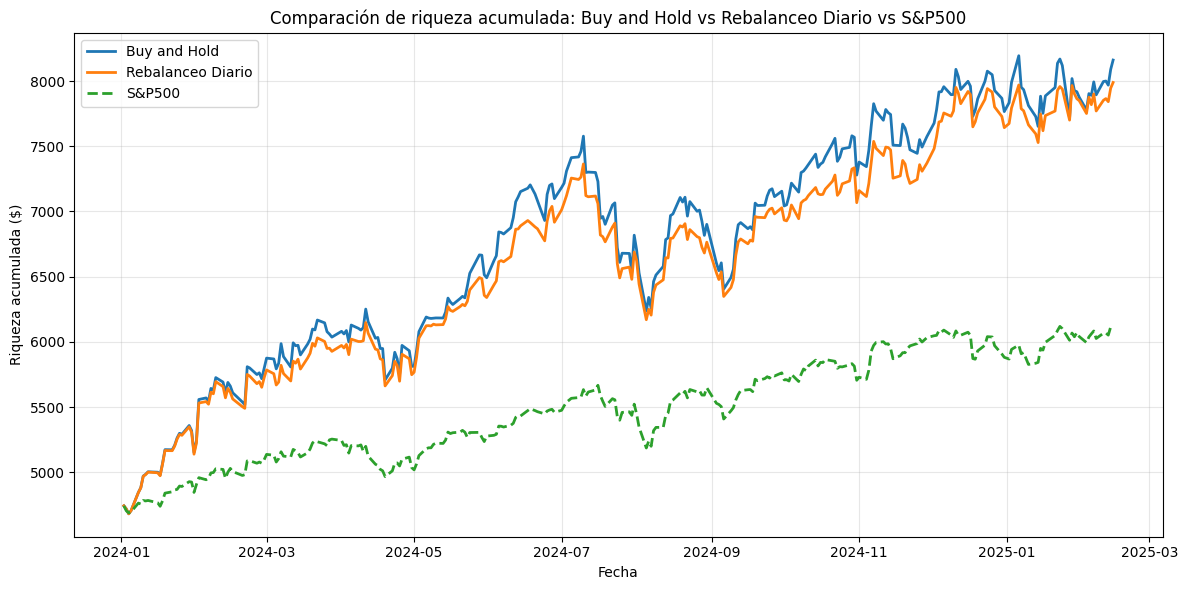

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(fechas, wealth_bh, label="Buy and Hold", linewidth=2)
plt.plot(fechas, wealth_rebal, label="Rebalanceo Diario", linewidth=2)
plt.plot(fechas, wealth_sp500, label="S&P500", linewidth=2, linestyle="--")

plt.title("Comparación de riqueza acumulada: Buy and Hold vs Rebalanceo Diario vs S&P500")
plt.xlabel("Fecha")
plt.ylabel("Riqueza acumulada ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("comparacion_estrategias.png", dpi=150)
plt.show()

## 8. Conclusiones

- Ambas estrategias (**Buy and Hold** y **Rebalanceo Diario**) superan ampliamente al **S&P500** en este período, ya que las 6 compañías tecnológicas seleccionadas tuvieron un desempeño excepcional frente al mercado general.
- **Buy and Hold** rinde ligeramente más que el **Rebalanceo Diario** en este caso, porque al no rebalancear se deja correr sin recortar a la acción que más subió (en este período, Nvidia), mientras que el rebalanceo diario "vende ganadores" constantemente para mantener los pesos iguales.
- Esto ilustra un principio conocido en finanzas: el rebalanceo diario reduce la concentración de riesgo y suaviza la dependencia de un solo activo, pero puede sacrificar algo de rendimiento cuando un activo individual tiene un rally muy fuerte y sostenido.
